## Checking of Energy Minimization

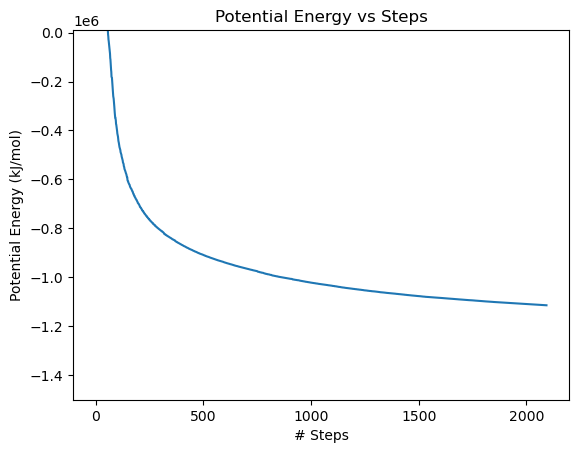

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("em_potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("# Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 10000)  # Set y-axis limits for better visualization
plt.show()

## Equilibration Plots

In [13]:
import subprocess
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

sim_dir = os.path.dirname(os.path.abspath("step6.1.xtc"))  # notebook working dir

# Derive .edr files from .xtc files (gmx energy reads .edr, not .xtc)
xtc_files = sorted(glob.glob("step6.*.xtc"))
edr_files = [f.replace(".xtc", ".edr") for f in xtc_files]

all_time = []
all_temp = []
all_press = []
step_labels = []

for edr_file, xtc_file in zip(edr_files, xtc_files):
    if not os.path.exists(edr_file):
        print(f"Warning: {edr_file} not found, skipping.")
        continue

    step_name = os.path.splitext(edr_file)[0]  # e.g. "step6.1"
    xvg_file = f"{step_name}_tp.xvg"

    result = subprocess.run(
        ["gmx", "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Temperature\nPressure\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    # xvg columns: time, Temperature, Pressure
    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    all_time.append(data[0])
    all_temp.append(data[1])
    all_press.append(data[2])
    step_labels.append(step_name)

print(f"\nLoaded data for steps: {step_labels}")


Processed step6.1.edr -> step6.1_tp.xvg
Processed step6.2.edr -> step6.2_tp.xvg
Processed step6.3.edr -> step6.3_tp.xvg
Processed step6.4.edr -> step6.4_tp.xvg
Processed step6.5.edr -> step6.5_tp.xvg
Processed step6.6.edr -> step6.6_tp.xvg

Loaded data for steps: ['step6.1', 'step6.2', 'step6.3', 'step6.4', 'step6.5', 'step6.6']


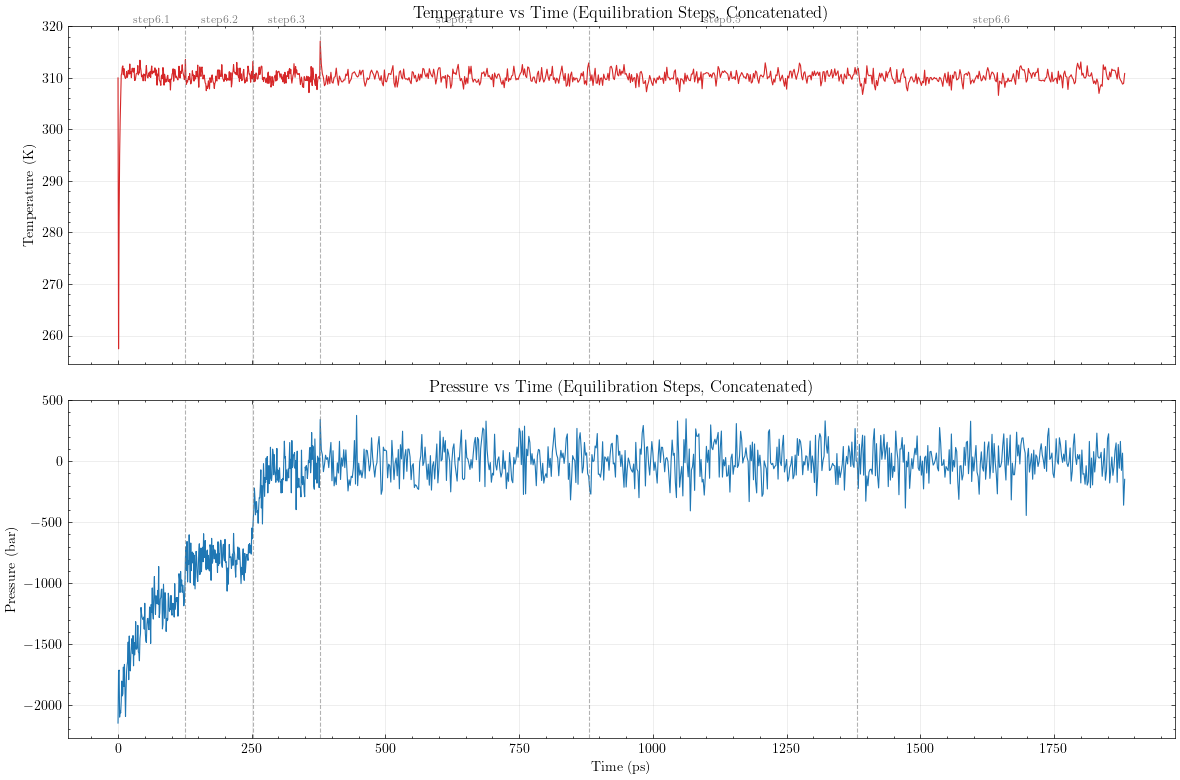

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")

# Concatenate consecutive steps into a single continuous time series
# Offset each step's time so it follows the previous one
concat_time = []
concat_temp = []
concat_press = []
time_offset = 0.0

for time, temp, press in zip(all_time, all_temp, all_press):
    concat_time.append(time + time_offset)
    concat_temp.append(temp)
    concat_press.append(press)
    time_offset += time[-1] - time[0] + (time[1] - time[0])  # advance by step duration + dt

concat_time = np.concatenate(concat_time)
concat_temp = np.concatenate(concat_temp)
concat_press = np.concatenate(concat_press)

# Add vertical lines at step boundaries
step_boundaries = []
t_offset = 0.0
for time in all_time[:-1]:
    t_offset += time[-1] - time[0] + (time[1] - time[0])
    step_boundaries.append(t_offset)

fig, (ax_temp, ax_press) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_temp.plot(concat_time, concat_temp, lw=0.8, color="tab:red")
ax_press.plot(concat_time, concat_press, lw=0.8, color="tab:blue")

for bnd in step_boundaries:
    ax_temp.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_press.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Annotate step labels at the top of the temperature plot
t_offset = 0.0
for i, (time, label) in enumerate(zip(all_time, step_labels)):
    mid = t_offset + (time[-1] - time[0]) / 2
    ax_temp.text(mid, ax_temp.get_ylim()[1], label, ha="center", va="bottom",
                 fontsize=8, color="gray")
    t_offset += time[-1] - time[0] + (time[1] - time[0])

ax_temp.set_title("Temperature vs Time (Equilibration Steps, Concatenated)")
ax_temp.set_ylabel("Temperature (K)")
ax_temp.grid(True, alpha=0.3)

ax_press.set_title("Pressure vs Time (Equilibration Steps, Concatenated)")
ax_press.set_xlabel("Time (ps)")
ax_press.set_ylabel("Pressure (bar)")
ax_press.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Box vectors

It is also advisable to verify that the box vectors have stabilized, ensuring a stable lateral area of the membrane (Box-X and Box-Y).

Note that box vectors only change during NPT ensemble dynamics. in NVT ensemble, all boundary conditions are fixed by definition.

Processed step6.3.edr -> step6.3_box.xvg
Processed step6.4.edr -> step6.4_box.xvg
Processed step6.5.edr -> step6.5_box.xvg
Processed step6.6.edr -> step6.6_box.xvg


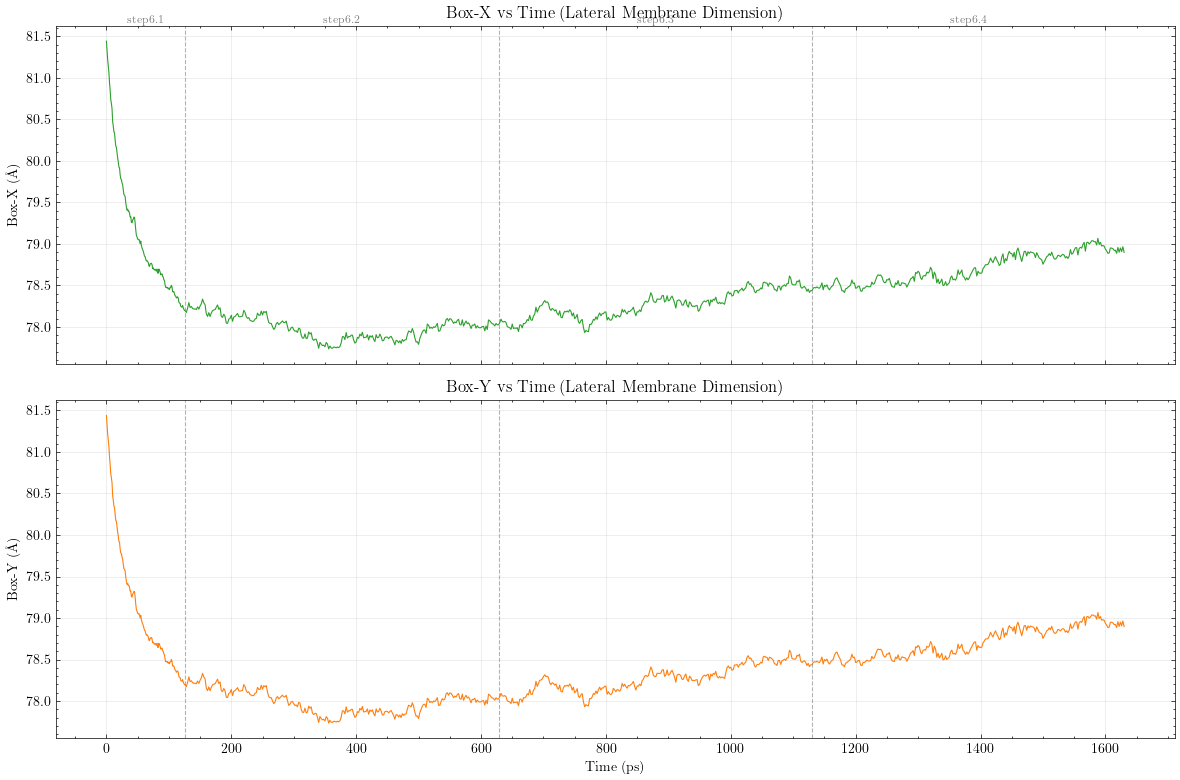

In [22]:
import subprocess
import os
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use("science")
# Extract Box-X and Box-Y from each equilibration step .edr file
all_box_time = []
all_boxx = []
all_boxy = []

for edr_file in edr_files[2:]:
    step_name = os.path.splitext(edr_file)[0]
    xvg_file = f"{step_name}_box.xvg"

    result = subprocess.run(
        ["gmx", "energy", "-f", edr_file, "-o", xvg_file],
        input=b"Box-X\nBox-Y\n0\n",
        capture_output=True,
    )

    if result.returncode != 0:
        print(f"gmx energy failed for {edr_file}:")
        print(result.stderr.decode(errors="replace"))
        continue
    else:
        print(f"Processed {edr_file} -> {xvg_file}")

    try:
        data = np.loadtxt(xvg_file, comments=["@", "#"], unpack=True)
    except Exception as e:
        print(f"Could not load {xvg_file}: {e}")
        continue

    # data[0]=time (ps), data[1]=Box-X (nm), data[2]=Box-Y (nm)
    all_box_time.append(data[0])
    all_boxx.append(data[1])
    all_boxy.append(data[2])

# Build concatenated time axis independently for box data
concat_box_time = []
box_time_offset = 0.0
for t in all_box_time:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    concat_box_time.append(t + box_time_offset)
    box_time_offset += t[-1] - t[0] + dt

concat_box_time = np.concatenate(concat_box_time)
concat_boxx = np.concatenate(all_boxx)
concat_boxy = np.concatenate(all_boxy)

# Step boundary positions on this time axis
box_boundaries = []
t_off = 0.0
for t in all_box_time[:-1]:
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    t_off += t[-1] - t[0] + dt
    box_boundaries.append(t_off)

# Plot
fig, (ax_x, ax_y) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax_x.plot(concat_box_time, concat_boxx * 10, lw=0.8, color="tab:green")   # nm -> Å
ax_y.plot(concat_box_time, concat_boxy * 10, lw=0.8, color="tab:orange")

for bnd in box_boundaries:
    ax_x.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)
    ax_y.axvline(bnd, color="gray", lw=0.8, ls="--", alpha=0.6)

# Step labels
t_off = 0.0
for t, label in zip(all_box_time, step_labels):
    dt = t[1] - t[0] if len(t) > 1 else 0.0
    mid = t_off + (t[-1] - t[0]) / 2
    ax_x.text(mid, ax_x.get_ylim()[1], label, ha="center", va="bottom",
              fontsize=8, color="gray")
    t_off += t[-1] - t[0] + dt

ax_x.set_title("Box-X vs Time (Lateral Membrane Dimension)")
ax_x.set_ylabel("Box-X (Å)")
ax_x.grid(True, alpha=0.3)

ax_y.set_title("Box-Y vs Time (Lateral Membrane Dimension)")
ax_y.set_xlabel("Time (ps)")
ax_y.set_ylabel("Box-Y (Å)")
ax_y.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Temperature Issue

A little concerned about the equilibrated temperature. Lipids can undergo phase transitions, right? So the system should be hot enough so as not to freeze the lipids. Is that the case @ 310K?

#### Response
Let me first check what lipids are actually in this membrane before giving a concrete answer. 


Good question. Looking at your actual lipid composition from the topology and README:

**Outer leaflet:** LPSA (E. coli R1 core-Lipid A, 35 molecules)  
**Inner leaflet:** PPPE (PE 16:0/16:1, 75), PVPG (PG 16:0/18:1, 20), PVCL2 (CL 16:0/18:1, 5)

**310 K is fine.** Here's why, per lipid species:

| Lipid | $T_m$ (approx.) | At 310 K |
|---|---|---|
| PPPE (PE 16:0/16:1) | ~285 K | ✅ well above $T_m$ |
| PVPG (PG 16:0/18:1) | ~271 K | ✅ well above $T_m$ |
| PVCL2 (CL 16:0/18:1) | <270 K | ✅ well above $T_m$ |
| LPSA (E. coli Lipid A) | ~303–308 K | ✅ marginally above $T_m$ |

The inner leaflet lipids are all safe — their monounsaturated sn-2 chains (16:1, 18:1) lower the $T_m$ well below room temperature. The critical one is **Lipid A** in the outer leaflet: E. coli hexa-acylated Lipid A has $T_m \approx 30$–35°C in divalent-cation buffers (your system has Ca²⁺), so 310 K (37°C) sits just above it.

A practical cross-check: the reference CHARMM-GUI equilibration for this exact G-OM system uses **310.15 K** as well (as stated in the README), and the reference Area Per Lipid values there are ~60–64 Å² — solidly in the **liquid-disordered (fluid) phase** range. Gel-phase values would be ~40–48 Å². You can compare against your own Box-X/Box-Y once stabilized (your equilibrated box of ~78–79 Å over 35 lipids per leaflet gives APL ≈ $\frac{(78.5)^2}{35} \approx 176$ Å² per leaflet, or about **63 Å²/lipid** for the outer leaflet — right on target).

So 310 K is the correct physiological temperature for this system and the membrane is in the fluid phase.